# Double-Peak Fit for Fixed-Gamma Shot Data

对 `QTL/shot/fixed_gamma_shot_*.csv` 中的 `mean_final_ratio` 做拟合。

模型形式是：`衰减基线 + 两个高斯峰`，并且直接以原始 `gamma` 作为自变量进行拟合。目标趋势是前面出现两个峰，然后随 `gamma` 增大整体下降。

In [21]:
from __future__ import annotations

import math
import os
import re
import tempfile
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import least_squares

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "mplconfig_codex"))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display


@dataclass
class FitResult:
    file_name: str
    shot_count: int | None
    params: np.ndarray
    gamma_dense: np.ndarray
    ratio_dense: np.ndarray
    gamma_data: np.ndarray
    ratio_data: np.ndarray
    sem_data: np.ndarray | None
    r2: float
    rmse: float
    peak_1_gamma: float
    peak_2_gamma: float


def extract_shot_count(path: Path) -> int | None:
    match = re.search(r"shot_(\d+)", path.stem)
    return int(match.group(1)) if match else None


def double_peak_decay_model(gamma: np.ndarray, params: np.ndarray) -> np.ndarray:
    baseline_floor, baseline_amp, baseline_decay, amp1, center1, width1, amp2, delta2, width2 = params
    center2 = center1 + delta2
    baseline = baseline_floor + baseline_amp * np.exp(-baseline_decay * gamma)
    peak1 = amp1 * np.exp(-0.5 * ((gamma - center1) / width1) ** 2)
    peak2 = amp2 * np.exp(-0.5 * ((gamma - center2) / width2) ** 2)
    return baseline + peak1 + peak2


def fit_single_dataset(frame: pd.DataFrame, ratio_column: str, sem_column: str | None, file_name: str, shot_count: int | None) -> FitResult:
    ordered = frame.sort_values("gamma_plot")
    gamma = ordered["gamma_plot"].to_numpy(dtype=float)
    ratio = ordered[ratio_column].to_numpy(dtype=float)
    sem = ordered[sem_column].to_numpy(dtype=float) if sem_column and sem_column in ordered.columns else None

    gamma_max = float(gamma.max())
    sigma = np.maximum(sem, 1e-3) if sem is not None else np.ones_like(ratio)

    first_peak_guesses = [0.45, 0.7, 1.0]
    second_peak_guesses = [2.0, 3.0, 4.5, 6.0]
    decay_guesses = [1e-4, 5e-4, 1e-3, 5e-3, 2e-2]

    floor_guess = max(min(ratio.min(), ratio[-1]) - 0.02, 0.0)
    amp_guess = max(ratio[0] - floor_guess, 0.05)

    lower = np.array([0.0, 0.0, 1e-8, 0.0, 0.0, 0.03, 0.0, 0.05, 0.05], dtype=float)
    upper = np.array([1.0, 1.0, 1.0, 1.0, min(2.0, gamma_max), max(4.0, gamma_max / 3.0), 1.0, gamma_max + 5.0, max(20.0, gamma_max / 2.0)], dtype=float)

    def residuals(params: np.ndarray) -> np.ndarray:
        return (double_peak_decay_model(gamma, params) - ratio) / sigma

    best = None
    best_cost = math.inf

    for first_gamma in first_peak_guesses:
        center1 = min(first_gamma, upper[4] - 1e-3)
        for second_gamma in second_peak_guesses:
            center2 = min(second_gamma, gamma_max)
            delta2 = max(center2 - center1, lower[7] + 1e-3)
            delta2 = min(delta2, upper[7] - 1e-3)
            for baseline_decay in decay_guesses:
                start = np.array([
                    floor_guess,
                    amp_guess,
                    baseline_decay,
                    0.05,
                    center1,
                    0.18,
                    0.08,
                    delta2,
                    1.10,
                ], dtype=float)
                try:
                    result = least_squares(residuals, start, bounds=(lower, upper), loss="soft_l1", max_nfev=10000)
                except ValueError:
                    continue
                if result.cost < best_cost:
                    best_cost = result.cost
                    best = result.x

    if best is None:
        raise RuntimeError(f"fit failed for {file_name}")

    gamma_dense = np.geomspace(1e-4, gamma.max() + 1.0, 800) - 1e-4
    gamma_dense[0] = 0.0
    ratio_dense = double_peak_decay_model(gamma_dense, best)
    fitted = double_peak_decay_model(gamma, best)
    ss_res = float(np.sum((ratio - fitted) ** 2))
    ss_tot = float(np.sum((ratio - np.mean(ratio)) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    rmse = float(np.sqrt(np.mean((ratio - fitted) ** 2)))

    return FitResult(
        file_name=file_name,
        shot_count=shot_count,
        params=best,
        gamma_dense=gamma_dense,
        ratio_dense=ratio_dense,
        gamma_data=gamma,
        ratio_data=ratio,
        sem_data=sem,
        r2=r2,
        rmse=rmse,
        peak_1_gamma=float(best[4]),
        peak_2_gamma=float(best[4] + best[7]),
    )


def make_summary_table(results: list[FitResult]) -> pd.DataFrame:
    rows = []
    for result in results:
        baseline_floor, baseline_amp, baseline_decay, amp1, center1, width1, amp2, delta2, width2 = result.params
        rows.append({
            "file_name": result.file_name,
            "shot_count": result.shot_count,
            "r2": result.r2,
            "rmse": result.rmse,
            "peak_1_gamma": result.peak_1_gamma,
            "peak_2_gamma": result.peak_2_gamma,
            "baseline_floor": baseline_floor,
            "baseline_amp": baseline_amp,
            "baseline_decay": baseline_decay,
            "peak_1_amp": amp1,
            "peak_1_width": width1,
            "peak_2_amp": amp2,
            "peak_2_width": width2,
        })
    summary = pd.DataFrame(rows)
    if summary.empty:
        return summary
    return summary.sort_values(["shot_count", "file_name"], na_position="last")


def save_plot(results: list[FitResult], ratio_column: str, output_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
    colors = ["#1f4e79", "#c23b22", "#2c6e49", "#7a3e9d"]

    for color, result in zip(colors, results):
        label = f"shot={result.shot_count}" if result.shot_count is not None else result.file_name
        ax.plot(result.gamma_data, result.ratio_data, "o", ms=4, color=color, alpha=0.55)
        ax.plot(result.gamma_dense, result.ratio_dense, color=color, lw=2.2, label=f"{label} fit")

    ax.set_xlabel("gamma")
    ax.set_ylabel(ratio_column)
    ax.set_xlim(0, 10)
    ax.set_ylim(0.65, 0.85)
    ax.grid(alpha=0.25)
    ax.legend(loc="best", fontsize=9)
    fig.suptitle(f"{ratio_column}: combined gamma-space double-peak fits", fontsize=14)
    fig.savefig(output_path, dpi=200)
    plt.close(fig)


In [22]:
candidate_dirs = [Path.cwd() / "QTL/shot", Path.cwd()]
input_dir = next((path for path in candidate_dirs if path.exists() and list(path.glob("fixed_gamma_shot_*.csv"))), candidate_dirs[0])
ratio_column = "mean_final_ratio"
sem_column = "sem_final_ratio"
summary_out = input_dir / "final_ratio_double_peak_fit_summary.csv"
plot_out = input_dir / "final_ratio_double_peak_fit.png"

files = sorted(
    input_dir.glob("fixed_gamma_shot_*.csv"),
    key=lambda path: (extract_shot_count(path) or 10**9, path.name),
)
files


[PosixPath('/Users/qiuyixian/Desktop/Research/QTL/code/QTL/shot/fixed_gamma_shot_512.csv'),
 PosixPath('/Users/qiuyixian/Desktop/Research/QTL/code/QTL/shot/fixed_gamma_shot_1024.csv'),
 PosixPath('/Users/qiuyixian/Desktop/Research/QTL/code/QTL/shot/fixed_gamma_shot_5000.csv'),
 PosixPath('/Users/qiuyixian/Desktop/Research/QTL/code/QTL/shot/fixed_gamma_shot_10000.csv')]

In [23]:
results = []
for path in files:
    frame = pd.read_csv(path)
    result = fit_single_dataset(
        frame=frame,
        ratio_column=ratio_column,
        sem_column=sem_column,
        file_name=path.name,
        shot_count=extract_shot_count(path),
    )
    results.append(result)

summary = make_summary_table(results)
summary.to_csv(summary_out, index=False)
save_plot(results, ratio_column=ratio_column, output_path=plot_out)

summary


,file_name,shot_count,r2,rmse,peak_1_gamma,peak_2_gamma,baseline_floor,baseline_amp,baseline_decay,peak_1_amp,peak_1_width,peak_2_amp,peak_2_width
0,fixed_gamma_shot_512.csv,512,0.901849,0.010430,0.684911,3.837801,1.990204e-14,6.949658e-01,2.380383e-03,0.048431,0.100820,0.082623,3.231919
1,fixed_gamma_shot_1024.csv,1024,0.950629,0.015456,0.711653,4.247748,5.696824e-01,1.483789e-01,1.841236e-02,0.049279,0.108850,0.066899,2.801809
2,fixed_gamma_shot_5000.csv,5000,0.845605,0.013255,0.712357,3.596328,6.731734e-01,6.436071e-09,1.000000e-08,0.030395,0.030000,0.122773,3.131197
3,fixed_gamma_shot_10000.csv,10000,0.946476,0.012567,0.732012,3.717247,5.758851e-09,7.061255e-01,2.748985e-03,0.045083,0.096452,0.111828,2.314645


Saved summary: /Users/qiuyixian/Desktop/Research/QTL/code/QTL/shot/final_ratio_double_peak_fit_summary.csv
Saved plot: /Users/qiuyixian/Desktop/Research/QTL/code/QTL/shot/final_ratio_double_peak_fit.png
shot=512: R^2=0.902, peak1=0.685, peak2=3.838, rmse=0.0104
shot=1024: R^2=0.951, peak1=0.712, peak2=4.248, rmse=0.0155
shot=5000: R^2=0.846, peak1=0.712, peak2=3.596, rmse=0.0133
shot=10000: R^2=0.946, peak1=0.732, peak2=3.717, rmse=0.0126


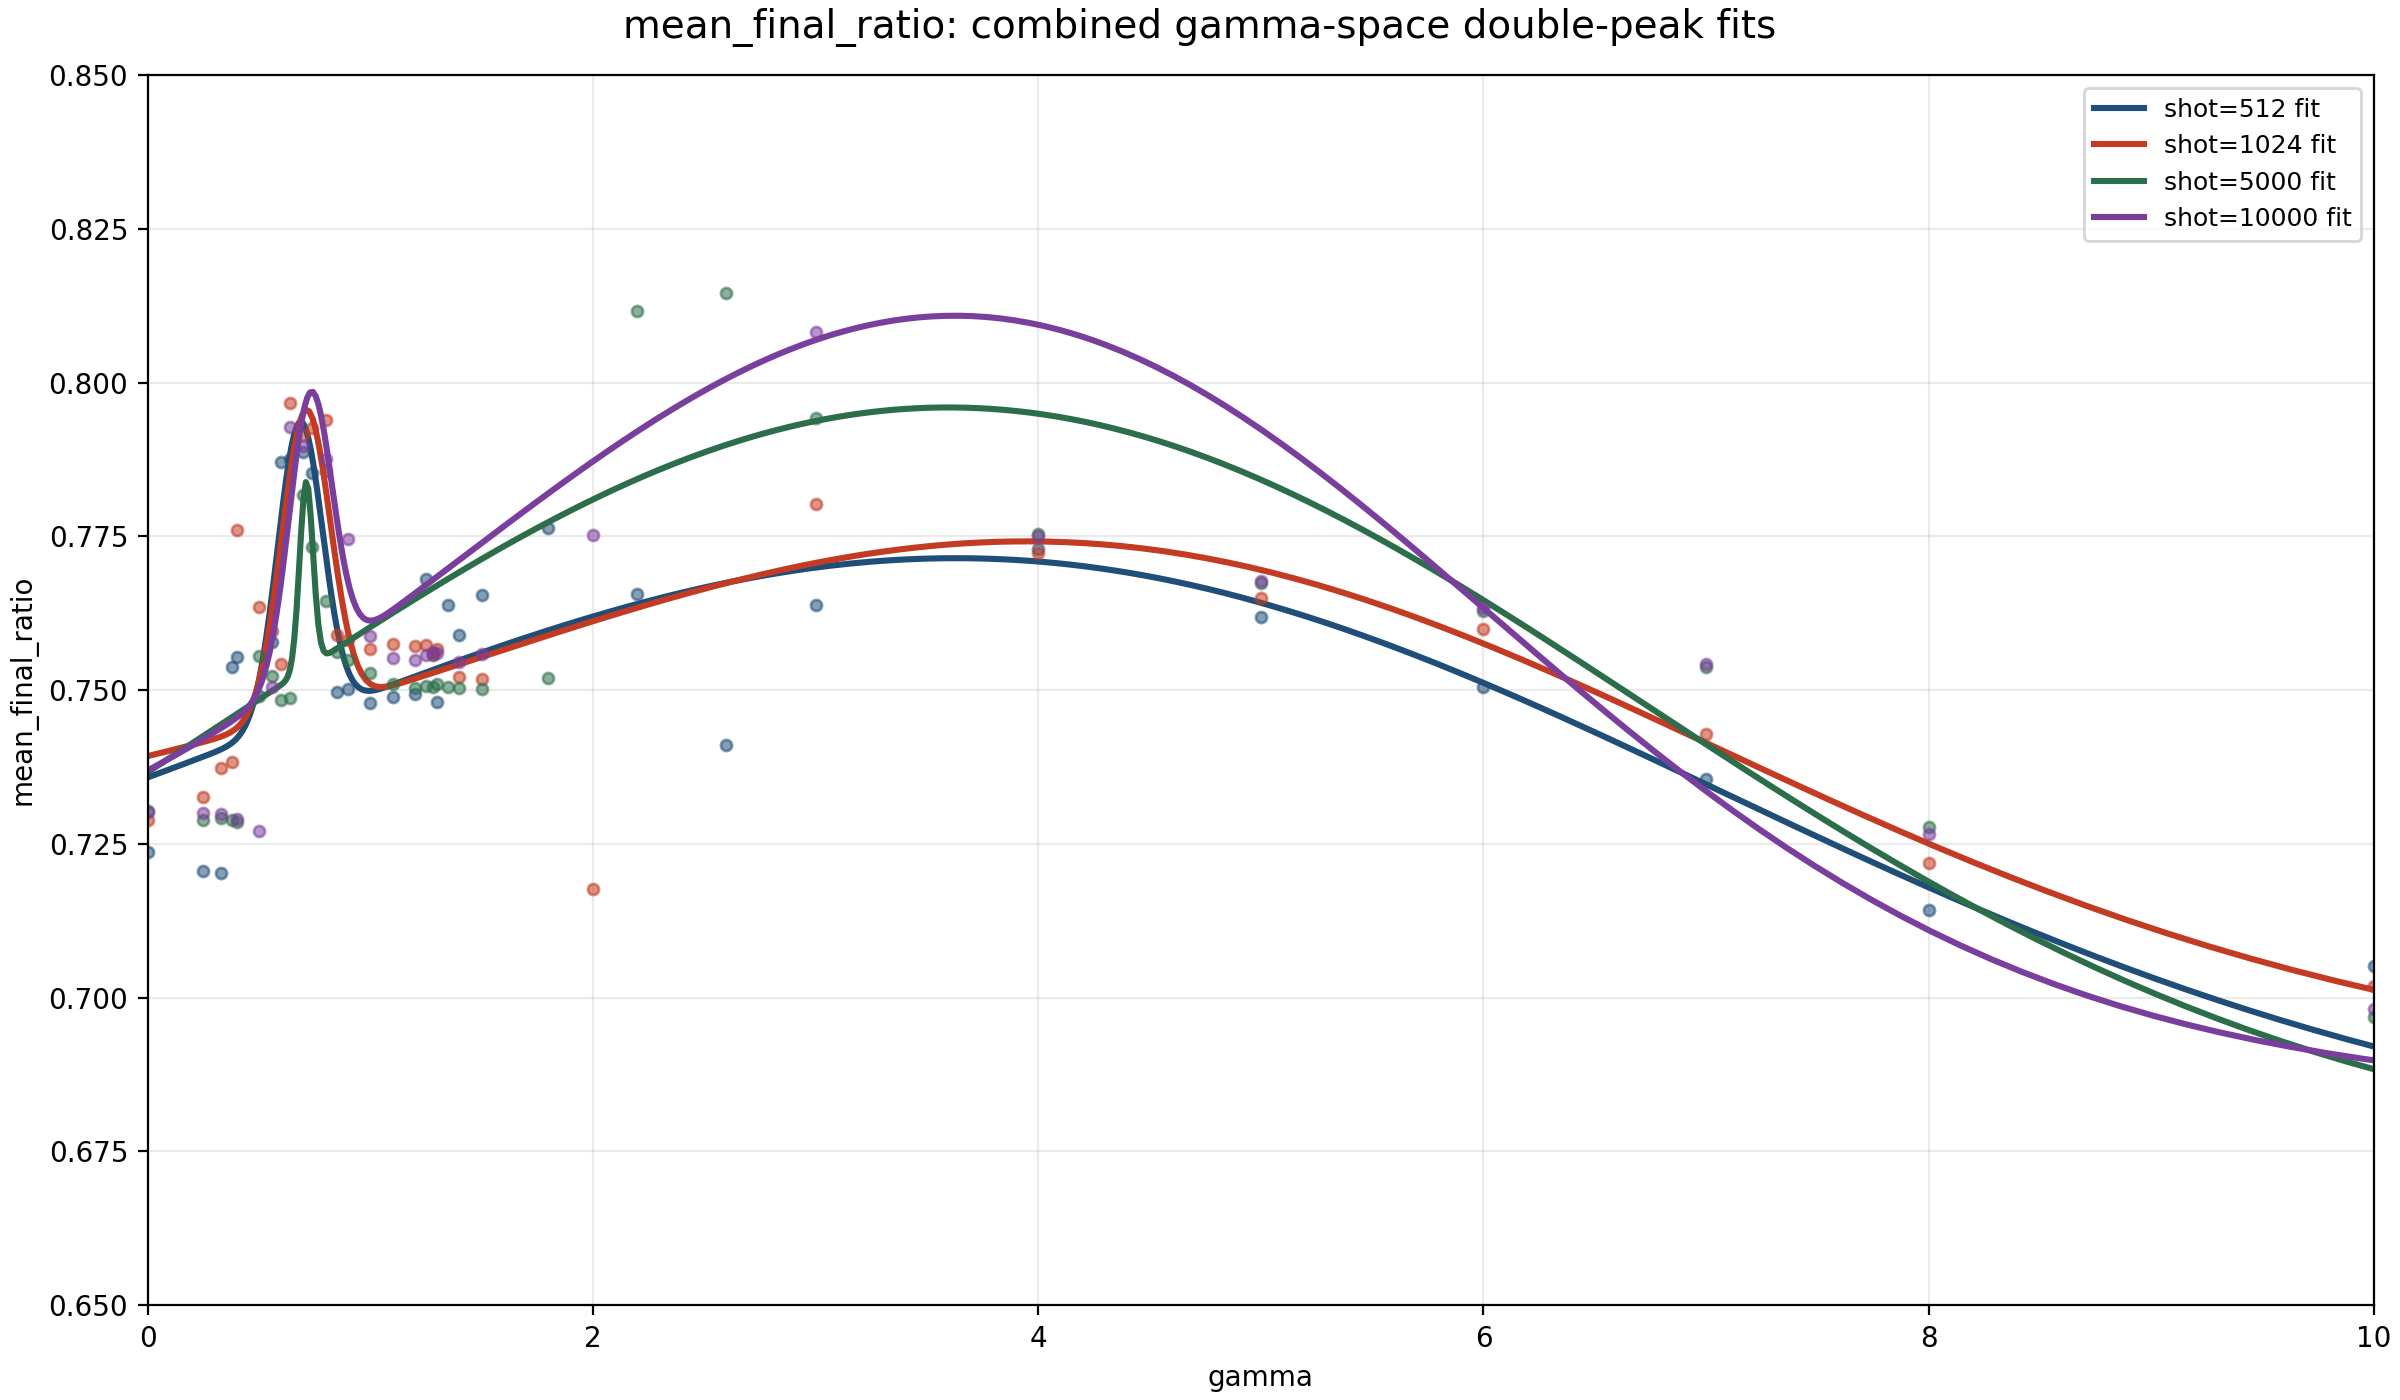

In [24]:
print(f"Saved summary: {summary_out}")
print(f"Saved plot: {plot_out}")
for result in results:
    shot_label = f"shot={result.shot_count}" if result.shot_count is not None else result.file_name
    print(f"{shot_label}: R^2={result.r2:.3f}, peak1={result.peak_1_gamma:.3f}, peak2={result.peak_2_gamma:.3f}, rmse={result.rmse:.4f}")
display(Image(filename=str(plot_out)))
